# 09 -- Manufacturing Plan

Composite layup plan, structural mass estimation, materials shopping list,
and step-by-step manufacturing procedure for the BWB UAV.

Prerequisites: design selected from catalog (notebook 06), validated (notebook 07).


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np

from src.parameterization.design_variables import BWBParams, params_from_vector

try:
    best_x = np.load('../output/best_x_v2.npy')
    params = params_from_vector(best_x)
    print('Loaded v2 optimized design')
except FileNotFoundError:
    params = BWBParams()
    print('Using default params')

from src.visualization.style import apply_style, COLORS
apply_style()


Loaded v2 optimized design


## 5. Composite Layup Plan

In [2]:
from src.manufacturing.composite import ManufacturingPlan

plan = ManufacturingPlan.default_bwb(params)
plan.print_layup_summary()


  COMPOSITE LAYUP PLAN
  body_upper — Body extrados (sandwich)
  Ply  Material                   Orient  t[mm]   gsm
  1    Carbon twill 2×2, 200 g/m²      0°   0.25   200
  2    Carbon twill 2×2, 200 g/m²    +45°   0.25   200
  3    Carbon twill 2×2, 200 g/m²    -45°   0.25   200
  4    Carbon twill 2×2, 200 g/m²      0°   0.25   200
  5    XPS foam core, 3 mm, 40 kg/m³      0°   3.00   120
  6    E-glass plain weave, 80 g/m²      0°   0.08    80
       TOTAL                               4.08  1637

  body_lower — Body intrados (sandwich)
  Ply  Material                   Orient  t[mm]   gsm
  1    Carbon twill 2×2, 200 g/m²      0°   0.25   200
  2    Carbon twill 2×2, 200 g/m²    +45°   0.25   200
  3    Carbon twill 2×2, 200 g/m²    -45°   0.25   200
  4    XPS foam core, 3 mm, 40 kg/m³      0°   3.00   120
  5    E-glass plain weave, 80 g/m²      0°   0.08    80
       TOTAL                               3.83  1292

  wing_upper — Wing extrados (monolithic)
  Ply  Material      

## 6. Structural Mass: Layup vs Empirical

In [3]:
plan.print_mass_breakdown()


  STRUCTURAL MASS BREAKDOWN (from layup)
  body_upper                    119 g
  body_lower                     94 g
  wing_skin_upper               120 g
  wing_skin_lower                80 g
  spar_caps                      87 g
  spar_web                       30 g
  leading_edge                   13 g
  control_surfaces               80 g
  fittings_glue_finish           93 g
  -----------------------------------
  TOTAL (layup)                 715 g
  TOTAL (empirical)             428 g
  Delta: +67%



## 7. Materials Shopping List

In [4]:
from src.systems.avionics import AvionicsSpec
avionics = AvionicsSpec.default_bwb()

plan.print_materials_bom()

print(f'Avionics cost:  {avionics.total_price_eur:.0f}\u20ac')
bom = plan.compute_materials_bom()
mat_cost = sum(item['price_eur'] for item in bom)
print(f'Materials cost:  {mat_cost:.0f}\u20ac')
print(f'TOTAL estimate: {avionics.total_price_eur + mat_cost:.0f}\u20ac (excl. tooling, consumables)')


  MATERIALS SHOPPING LIST (incl. 20% waste)
  Material                            Qty    Price
  --------------------------------------------------
  Aramide tape, 50 g/m² (hinges)  0.03 m²     0.5€
  Carbon twill 2×2, 200 g/m²      2.30 m²    57.5€
  Carbon unidirectional, 300 g/m²  0.20 m²     7.1€
  XPS foam core, 2 mm, 40 kg/m³   0.09 m²     0.2€
  XPS foam core, 3 mm, 40 kg/m³   0.26 m²     0.8€
  XPS foam core, 5 mm, 40 kg/m³   0.04 m²     0.2€
  E-glass plain weave, 80 g/m²    0.29 m²     1.5€
  Rohacell 51 IG-F, 2 mm, 52 kg/m³  0.02 m²     0.9€
  Epoxy resin system (prepreg ratio 42%)  0.42 kg    12.7€
  --------------------------------------------------
  TOTAL                                      81.4€

Avionics cost:  229€
Materials cost:  81€
TOTAL estimate: 310€ (excl. tooling, consumables)


## 8. Manufacturing Procedure

In [5]:
from src.manufacturing.composite import print_manufacturing_steps
print_manufacturing_steps()


MANUFACTURING PROCEDURE — Moule femelle + prépreg carbone
══════════════════════════════════════════════════════════

Phase 1 — Outillage (1-2 semaines)
  1. Exporter STEP OML depuis le pipeline (export_aircraft_step)
  2. Usiner moules femelles CNC (MDF 30mm ou tooling board Cibatool)
     - 2 demi-coques body (extrados/intrados), plan de joint au plan de symétrie
     - 2 demi-coques aile droite (extrados/intrados)
     - Miroir pour aile gauche (ou usiner 2 moules supplémentaires)
  3. Poncer moules (grain 400 → 800 → 1200)
  4. Bouche-porer (2 couches polyuréthane), poncer fin
  5. Cirer (3 couches de cire Frekote + 1 couche PVA)

Phase 2 — Découpe noyaux (2-3 jours)
  6. Découpe mousse XPS au fil chaud depuis profils CAD (.dat)
     - Noyaux body : 3 tranches (center, mid, blend)
     - Noyaux aile : 4 tranches par demi-aile (root, 25%, 50%, tip)
  7. Ponçage des noyaux aux gabarits (cales profilées)
  8. Découpe logements : batterie, FC, ESC, servos dans les noyaux

Phase 3 — St

## 5. Mass & Cost Visualization

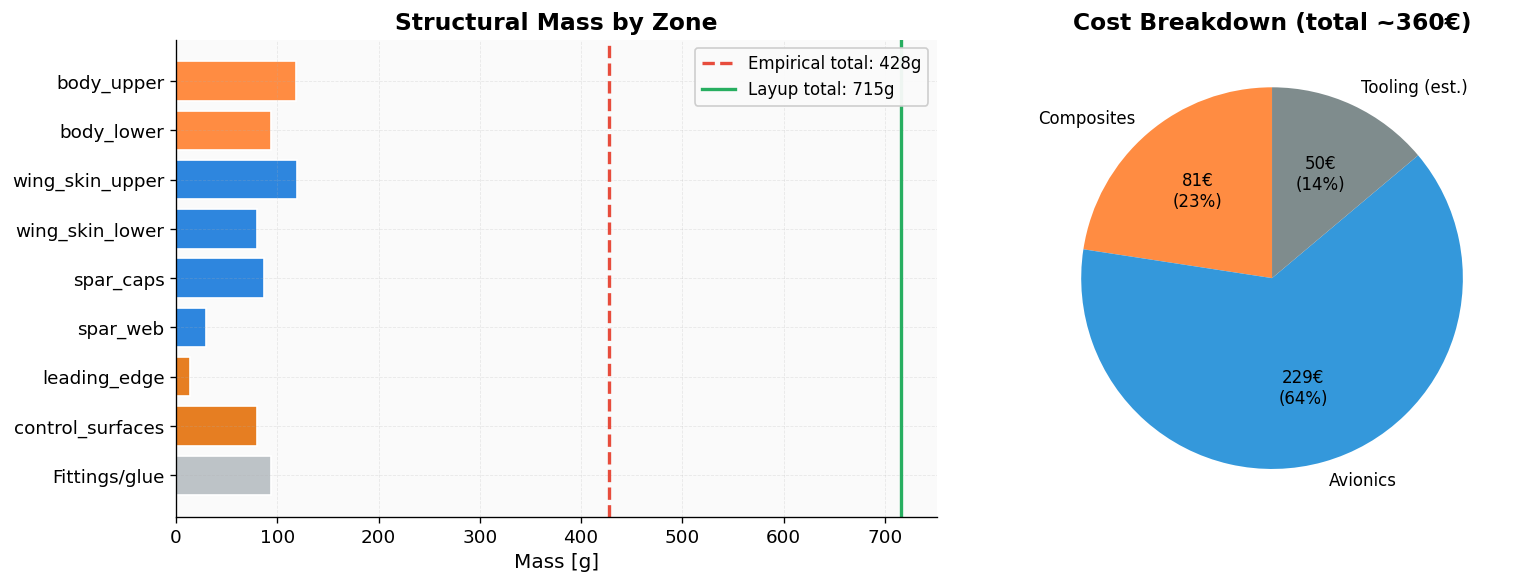

In [6]:
import matplotlib.pyplot as plt
from src.visualization.style import COLORS

zones = plan.estimate_composite_mass(params)
total_layup = zones.pop('total_kg')
fittings = zones.pop('fittings_glue_finish')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart: structural mass by zone (layup vs empirical) ---
zone_names = list(zones.keys())
zone_masses = [v * 1000 for v in zones.values()]  # kg -> g
zone_colors = [COLORS['body'] if 'body' in z else
               COLORS['wing'] if 'wing' in z or 'spar' in z else
               COLORS['elevon'] if 'control' in z or 'leading' in z else
               COLORS['secondary'] for z in zone_names]

bars = ax1.barh(zone_names, zone_masses, color=zone_colors, edgecolor='white')
ax1.barh(['Fittings/glue'], [fittings * 1000], color=COLORS['light'], edgecolor='white')

from src.parameterization.bwb_aircraft import estimate_structural_mass
emp = estimate_structural_mass(params) * 1000
ax1.axvline(emp, color=COLORS['infeasible'], linestyle='--', linewidth=2,
            label=f'Empirical total: {emp:.0f}g')
ax1.axvline(total_layup * 1000, color=COLORS['feasible'], linestyle='-', linewidth=2,
            label=f'Layup total: {total_layup*1000:.0f}g')
ax1.set_xlabel('Mass [g]')
ax1.set_title('Structural Mass by Zone', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.invert_yaxis()

# --- Pie chart: total cost breakdown ---
mat_cost = sum(item['price_eur'] for item in plan.compute_materials_bom())
avio_cost = avionics.total_price_eur
tooling_est = 50  # rough estimate for MDF + CNC time

cost_labels = ['Composites', 'Avionics', 'Tooling (est.)']
cost_values = [mat_cost, avio_cost, tooling_est]
cost_colors = [COLORS['body'], COLORS['avionics'], COLORS['secondary']]

ax2.pie(cost_values, labels=cost_labels, colors=cost_colors,
        autopct=lambda p: f'{p*sum(cost_values)/100:.0f}\u20ac\n({p:.0f}%)',
        startangle=90, textprops={'fontsize': 10})
ax2.set_title(f'Cost Breakdown (total ~{sum(cost_values):.0f}\u20ac)',
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/manufacturing_mass_cost.png', dpi=150, bbox_inches='tight')
plt.show()